<a href="https://colab.research.google.com/github/Timmythaw/langgraph-adk-edu-comparison/blob/main/notebooks/04_ragas_eval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Notebook 04 — RAGAS RAG Faithfulness Evaluation

> **Fully self-contained.** No dependency on notebooks 01, 02, or 03.
> Builds both systems, runs all 3 scenarios, evaluates with RAGAS.

## What RAGAS Measures

| Metric | What it measures | Why it matters |
|---|---|---|
| **Faithfulness** | Is output factually grounded in retrieved chunks? | Detects hallucinations |
| **Answer Relevancy** | Is output relevant to the input prompt? | Detects off-topic responses |
| **Context Precision** | Did retriever fetch the *right* chunks? | Measures retrieval quality |
| **Context Recall** | Did retriever fetch *all* needed chunks? | Measures retrieval completeness |

## Key Design: Context-Saving Hook

RAGAS requires `(question, answer, contexts)` triples.
This notebook wraps `retrieve_course_materials()` with a **thread-safe context store**
that captures every retrieved chunk automatically during system runs.

**Colab Secrets required:**
- `GOOGLE_CLOUD_PROJECT`
- `GOOGLE_CLOUD_LOCATION`
- `VERTEX_AI_SEARCH_DATASTORE_ID`
- `LANGSMITH_API_KEY`

| Section | What happens |
|---|---|
| 1 | Install dependencies |
| 2 | Secrets, auth, Vertex AI init |
| 3 | Context-saving Vertex AI Search tool |
| 4 | Build LangGraph system |
| 5 | Build Google ADK system |
| 6 | Runners |
| 7 | Run evaluation scenarios + capture contexts |
| 8 | Build RAGAS datasets |
| 9 | Run RAGAS evaluation |
| 10 | Aggregate results |
| 11 | Visualisations (bar, radar, heatmap) |
| 12 | Export CSV + Markdown report |

## 1 — Install Dependencies

In [ ]:
!pip install ragas langgraph langchain-google-genai langchain-google-community \
    google-adk google-cloud-aiplatform google-cloud-discoveryengine \
    google-api-python-client google-auth-httplib2 google-auth-oauthlib \
    langsmith datasets -q
print("All packages installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.5/168.5 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.9/140.9 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 134.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.9/543.9 kB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.2/178.2 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 125.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.7/360.7 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.

## 2 — Secrets, Auth & Config

In [ ]:
import os
from google.colab import userdata, auth

PROJECT_ID   = userdata.get("GOOGLE_CLOUD_PROJECT")
LOCATION     = userdata.get("GOOGLE_CLOUD_LOCATION")
DATASTORE_ID = userdata.get("VERTEX_AI_SEARCH_DATASTORE_ID")

os.environ["GOOGLE_CLOUD_PROJECT"]      = PROJECT_ID
os.environ["GOOGLE_CLOUD_LOCATION"]     = LOCATION
os.environ["GOOGLE_GENAI_USE_VERTEXAI"] = "1"
os.environ["LANGCHAIN_TRACING_V2"]      = "true"
os.environ["LANGCHAIN_API_KEY"]         = userdata.get("LANGSMITH_API_KEY")
os.environ["LANGCHAIN_PROJECT"]         = "langgraph-adk-edu-comparison"
os.environ["LANGCHAIN_ENDPOINT"]        = "https://api.smith.langchain.com"

auth.authenticate_user()

import vertexai
from google.cloud import aiplatform
vertexai.init(project=PROJECT_ID, location="us-central1")
aiplatform.init(project=PROJECT_ID, location="us-central1")

print("Project  :", PROJECT_ID[:20])
print("Location :", LOCATION)
print("Datastore:", DATASTORE_ID[:20])

Project  : edu-teacher-assistan
Location : global
Datastore: curriculum-connector


## 3 — Context-Saving Vertex AI Search Tool

> **This is the key hook.** Every call to `retrieve_course_materials()` stores
> retrieved chunks in `CONTEXT_STORE[current_run_key]`.
> After each system run, we harvest those chunks as the RAGAS `contexts` field.

In [ ]:
from google.cloud import discoveryengine_v1 as discoveryengine
from collections import defaultdict
import threading

# Thread-safe context store
# Key: run_key string set before each system invocation
# Value: list of retrieved chunk strings
CONTEXT_STORE: dict[str, list[str]] = defaultdict(list)
_current_run_key = threading.local()  # thread-local so async ADK runs don't clash

def set_run_key(key: str):
    """Call before each system invocation to tag which run retrieval belongs to."""
    _current_run_key.value = key
    CONTEXT_STORE[key] = []  # reset for fresh run

def get_run_key() -> str:
    return getattr(_current_run_key, "value", "__default__")

def retrieve_course_materials(query: str, page_size: int = 5) -> str:
    """Search curriculum datastore for relevant course materials.

    Automatically stores retrieved chunks in CONTEXT_STORE for RAGAS evaluation.

    Args:
        query: Natural language search query.
        page_size: Number of results to retrieve.

    Returns:
        Concatenated snippet text, or 'No relevant materials found.'
    """
    client = discoveryengine.SearchServiceClient()
    serving_config = (
        f"projects/{PROJECT_ID}/locations/{LOCATION}"
        f"/collections/default_collection/dataStores/{DATASTORE_ID}"
        f"/servingConfigs/default_config"
    )
    request = discoveryengine.SearchRequest(
        serving_config=serving_config, query=query, page_size=page_size,
        content_search_spec=discoveryengine.SearchRequest.ContentSearchSpec(
            snippet_spec=discoveryengine.SearchRequest.ContentSearchSpec.SnippetSpec(
                return_snippet=True
            ),
            summary_spec=discoveryengine.SearchRequest.ContentSearchSpec.SummarySpec(
                summary_result_count=min(page_size, 5), include_citations=True,
            ),
        ),
    )
    response = client.search(request)
    snippets = []
    for result in response.results:
        doc = result.document
        if doc.derived_struct_data:
            for s in doc.derived_struct_data.get("snippets", []):
                text = s.get("snippet", "").strip()
                if text:
                    snippets.append(text)

    # ── Context-saving hook ──────────────────────────────────────────
    run_key = get_run_key()
    CONTEXT_STORE[run_key].extend(snippets)
    # ────────────────────────────────────────────────────────────────

    return "\n\n---\n\n".join(snippets) if snippets else "No relevant materials found."

print("Context-saving Vertex AI Search tool ready.")
print("CONTEXT_STORE will capture chunks keyed by run_key.")

Context-saving Vertex AI Search tool ready.
CONTEXT_STORE will capture chunks keyed by run_key.


## 4 — Build LangGraph System

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, AIMessage
from typing import TypedDict, Annotated, Literal
import operator

class TeacherState(TypedDict):
    messages:         Annotated[list, operator.add]
    task_type:        str
    course_materials: str
    draft_output:     str
    final_output:     str
    hitl_decision:    str

lg_orchestrator_llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-pro", vertexai=True, project=PROJECT_ID,
    location="us-central1", max_output_tokens=4096, stream_usage=True,
    model_kwargs={"thinking": {"thinking_budget": 1024}},
)
lg_worker_llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash", vertexai=True, project=PROJECT_ID,
    location="us-central1", max_output_tokens=4096, stream_usage=True,
    model_kwargs={"thinking": {"thinking_budget": 512}},
)
print("LangGraph models ready.")

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3553: UserWarning: WARNING! stream_usage is not default parameter.
                stream_usage was transferred to model_kwargs.
                Please confirm that stream_usage is what you intended.
  exec(code_obj, self.user_global_ns, self.user_ns)


LangGraph models ready.


In [ ]:
def router_node(state: TeacherState) -> TeacherState:
    user_msg = state["messages"][-1].content
    lower = user_msg.lower()
    if any(k in lower for k in ["email", "send", "announcement", "draft"]):
        task = "email"
    elif any(k in lower for k in ["lesson plan", "outline", "lecture"]):
        task = "lessonplan"
    elif any(k in lower for k in ["quiz", "multiple choice", "question", "mcq"]):
        task = "quiz"
    else:
        prompt = (
            "Classify into exactly one of: lessonplan / quiz / email.\n"
            f"Request: {user_msg}\nReply with ONLY the task name."
        )
        raw = lg_orchestrator_llm.invoke([HumanMessage(content=prompt)]).content.strip().lower()
        task = raw if raw in ["lessonplan", "quiz", "email"] else "lessonplan"
    return {**state, "task_type": task}

def route_to_agent(state):
    return {"lessonplan": "lessonplanner", "quiz": "quizcontent", "email": "emaildrafter"}[state["task_type"]]

def lesson_planner_node(state):
    user_query = state["messages"][-1].content
    materials = retrieve_course_materials(user_query, page_size=6)
    prompt = (
        "You are an expert curriculum designer at Mae Fah Luang University.\n\n"
        f"Course Materials:\n{materials}\n\nInstructor Request:\n{user_query}\n\n"
        "Generate a comprehensive 90-minute lesson plan: Learning Objectives, timing breakdown, teaching methods, assessment strategy, required materials."
    )
    response = lg_worker_llm.invoke([HumanMessage(content=prompt)])
    return {**state, "course_materials": materials, "final_output": response.content,
            "messages": state["messages"] + [AIMessage(content=response.content)]}

def quiz_content_node(state):
    user_query = state["messages"][-1].content
    materials = retrieve_course_materials(user_query, page_size=8)
    prompt = (
        "You are a quiz content specialist at Mae Fah Luang University.\n\n"
        f"Course Materials:\n{materials}\n\nTopic: {user_query}\n\n"
        "Generate exactly 10 multiple-choice questions as a JSON array only.\n"
        'Each item: {"question":"...","options":["A.","B.","C.","D."],"correct_index":0,"explanation":"..."}'
    )
    response = lg_worker_llm.invoke([HumanMessage(content=prompt)])
    return {**state, "course_materials": materials, "draft_output": response.content}

def quiz_publisher_node(state):
    prompt = (
        f"Quiz JSON:\n{state['draft_output']}\n\n"
        "Present the quiz cleanly: number each question, list A/B/C/D options, mark correct, include explanation."
    )
    response = lg_worker_llm.invoke([HumanMessage(content=prompt)])
    return {**state, "final_output": response.content,
            "messages": state["messages"] + [AIMessage(content=response.content)]}

def email_drafter_node(state):
    user_query = state["messages"][-1].content
    materials = retrieve_course_materials(user_query, page_size=2)
    prompt = (
        "You are a professional email drafting assistant for a university lecturer at Mae Fah Luang University.\n\n"
        f"Context:\n{materials}\n\nDraft a professional email based on:\n{user_query}\n\n"
        "Format EXACTLY as:\nSUBJECT: <subject line>\n\nBODY:\n<email body>\n\nUse formal university tone."
    )
    response = lg_worker_llm.invoke([HumanMessage(content=prompt)])
    return {**state, "course_materials": materials, "draft_output": response.content}

def hitl_approval_node(state):
    return {**state, "hitl_decision": "approved"}

def email_sender_node(state):
    msg = f"Email approved and sent.\n\n{state['draft_output']}" if state["hitl_decision"] == "approved" else f"Email rejected.\n{state['draft_output']}"
    return {**state, "final_output": msg,
            "messages": state["messages"] + [AIMessage(content=msg)]}

def route_after_hitl(state):
    return "emailsender"

print("LangGraph nodes defined.")

LangGraph nodes defined.


In [ ]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()
builder = StateGraph(TeacherState)
builder.add_node("router",        router_node)
builder.add_node("lessonplanner", lesson_planner_node)
builder.add_node("quizcontent",   quiz_content_node)
builder.add_node("quizpublisher", quiz_publisher_node)
builder.add_node("emaildrafter",  email_drafter_node)
builder.add_node("hitlapproval",  hitl_approval_node)
builder.add_node("emailsender",   email_sender_node)
builder.set_entry_point("router")
builder.add_conditional_edges("router", route_to_agent)
builder.add_edge("lessonplanner", END)
builder.add_edge("quizcontent",   "quizpublisher")
builder.add_edge("quizpublisher", END)
builder.add_edge("emaildrafter",  "hitlapproval")
builder.add_conditional_edges("hitlapproval", route_after_hitl)
builder.add_edge("emailsender",   END)
lg_graph = builder.compile(checkpointer=checkpointer)
print("LangGraph compiled:", list(lg_graph.get_graph().nodes.keys()))

LangGraph compiled: ['__start__', 'router', 'lessonplanner', 'quizcontent', 'quizpublisher', 'emaildrafter', 'hitlapproval', 'emailsender', '__end__']


/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


## 5 — Build Google ADK System

In [ ]:
import google.adk
from google.adk.agents import LlmAgent, SequentialAgent
from google.adk.runners import Runner
from google.adk.sessions import InMemorySessionService
from google.adk.tools import FunctionTool
from google.adk.tools.agent_tool import AgentTool
from google.adk.models.google_llm import Gemini
from google.genai import types

resilient_http = types.HttpOptions(
    retry_options=types.HttpRetryOptions(
        attempts=5, initial_delay=5.0,
        http_status_codes=[408, 429, 500, 502, 503, 504]
    )
)
adk_pro   = Gemini(model="gemini-2.5-pro",   http_options=resilient_http,
    generate_content_config=types.GenerateContentConfig(
        thinking_config=types.ThinkingConfig(thinking_budget=1024)))
adk_flash = Gemini(model="gemini-2.5-flash", http_options=resilient_http,
    generate_content_config=types.GenerateContentConfig(
        thinking_config=types.ThinkingConfig(thinking_budget=512)))

adk_lesson_planner = LlmAgent(
    name="lesson_planner_agent", model=adk_flash,
    description="Creates detailed lesson plans.",
    instruction="""You are an expert curriculum designer at Mae Fah Luang University.
1. Use `retrieve_course_materials` (page_size=6) to fetch relevant content.
2. Generate a 90-minute lesson plan: Learning Objectives, timing, teaching methods, assessment, materials.""",
    tools=[retrieve_course_materials]
)

quiz_content_agent = LlmAgent(
    name="quiz_content_agent", model=adk_flash,
    description="Generates quiz questions as JSON.",
    instruction="""You are a quiz specialist at Mae Fah Luang University.
1. Use `retrieve_course_materials` (page_size=8).
2. Generate exactly 10 MCQ questions as a valid JSON array.
Each item: {"question":"...","options":["A.","B.","C.","D."],"correct_index":0,"explanation":"..."}""",
    tools=[retrieve_course_materials], output_key="quiz_questions_json"
)
quiz_publisher_agent = LlmAgent(
    name="quiz_publisher_agent", model=adk_flash,
    description="Formats and presents the quiz.",
    instruction="You are a quiz publisher. Quiz JSON: {quiz_questions_json}\nPresent cleanly: numbered questions, A/B/C/D, mark correct, include explanation.",
    tools=[]
)
adk_quiz_generator = SequentialAgent(
    name="quiz_generator_agent",
    description="Generates a 10-question MCQ quiz.",
    sub_agents=[quiz_content_agent, quiz_publisher_agent]
)

email_drafter_agent = LlmAgent(
    name="email_drafter_agent", model=adk_flash,
    description="Drafts a professional email to students.",
    instruction="""You are a professional email drafting assistant for Mae Fah Luang University.
Draft a professional email based on the instructor's request.
Format EXACTLY as:
SUBJECT: <subject line>

BODY:
<email body>

Use formal university tone.""",
    output_key="email_draft"
)

def send_email_to_students(subject: str, body: str) -> dict:
    """Send email to all students enrolled in the course.

    Args:
        subject: The email subject line.
        body: The complete email body.

    Returns:
        Confirmation dict with status and recipient count.
    """
    return {"status": "sent", "subject": subject, "recipients": "all_students"}

def auto_approve_callback(tool, args, tool_context, **kwargs):
    return None

email_sender_agent = LlmAgent(
    name="email_sender_agent", model=adk_flash,
    description="Sends approved email to students.",
    instruction="""You are an email dispatch agent.
The email draft is: {email_draft}
1. Parse the draft to extract SUBJECT and BODY.
2. Call send_email_to_students with the subject and body.
3. Report the result to the instructor.""",
    tools=[FunctionTool(func=send_email_to_students)],
    before_tool_callback=auto_approve_callback
)
adk_email_agent = SequentialAgent(
    name="email_agent",
    description="Drafts then sends student email.",
    sub_agents=[email_drafter_agent, email_sender_agent]
)

adk_root = LlmAgent(
    name="teacher_assistant_orchestrator", model=adk_pro,
    description="Root AI Teaching Assistant for MFU instructors.",
    instruction="""You are the AI Teaching Assistant for Mae Fah Luang University instructors.
Help with: Lesson Plans, Quizzes, Emails.
Identify task type, delegate to specialist agent, report full result.""",
    tools=[AgentTool(agent=adk_lesson_planner),
           AgentTool(agent=adk_quiz_generator),
           AgentTool(agent=adk_email_agent)]
)
print("ADK root orchestrator ready.")

ADK root orchestrator ready.


/usr/local/lib/python3.12/dist-packages/google/adk/features/_feature_decorator.py:72: UserWarning: [EXPERIMENTAL] feature FeatureName.PLUGGABLE_AUTH is enabled.
  check_feature_enabled()


## 6 — Runners

In [ ]:
import uuid, time, asyncio
from langsmith import traceable
from langsmith.run_helpers import get_current_run_tree

USERID = "mfu-instructor-ragas"
ADK_APP_NAME = "teacher-assistant-adk-ragas"
adk_session_service = InMemorySessionService()
adk_runner = Runner(agent=adk_root, app_name=ADK_APP_NAME, session_service=adk_session_service)

@traceable(name="lg_ragas_run", run_type="chain",
           metadata={"framework": "LangGraph", "notebook": "04_ragas"})
def lg_run(user_input: str, run_key: str):
    set_run_key(run_key)
    thread_id = str(uuid.uuid4())
    config = {"configurable": {"thread_id": thread_id},
              "metadata": {"run_key": run_key, "framework": "LangGraph"}}
    init_state = {"messages": [HumanMessage(content=user_input)],
                  "task_type": "", "course_materials": "",
                  "draft_output": "", "final_output": "", "hitl_decision": ""}
    start = time.time()
    result = lg_graph.invoke(init_state, config)
    latency = round(time.time() - start, 2)
    contexts = list(CONTEXT_STORE.get(run_key, []))
    print(f"  [LangGraph] {latency}s | {len(contexts)} context chunks captured")
    return result.get("final_output", ""), latency, contexts

@traceable(name="adk_ragas_run", run_type="chain",
           metadata={"framework": "Google ADK", "notebook": "04_ragas"})
async def adk_run(user_input: str, run_key: str):
    set_run_key(run_key)
    session_id = str(uuid.uuid4())
    await adk_session_service.create_session(
        app_name=ADK_APP_NAME, user_id=USERID, session_id=session_id)
    message = types.Content(role="user", parts=[types.Part(text=user_input)])
    start = time.time()
    final_response = ""
    async for event in adk_runner.run_async(
        user_id=USERID, session_id=session_id, new_message=message):
        if event.is_final_response() and event.content:
            final_response = event.content.parts[0].text.strip()
    latency = round(time.time() - start, 2)
    contexts = list(CONTEXT_STORE.get(run_key, []))
    print(f"  [ADK] {latency}s | {len(contexts)} context chunks captured")
    return final_response, latency, contexts

print("Runners ready.")

Runners ready.


## 7 — Run Evaluation Scenarios + Capture Contexts

> Note: email scenario is included for completeness but RAGAS
> Faithfulness / Context metrics are most meaningful for **lesson_plan** and **quiz**
> since those tasks are heavily retrieval-dependent.

In [ ]:
SCENARIOS = {
    "lesson_plan": "Create a 90-minute lesson plan for week 1 on Software Testing for second-year Software Engineering students. Align it with the course materials.",
    "quiz":        "Generate 10 multiple-choice questions on Software Testing from the course materials.",
    "email":       "Draft and send an email to all students reminding them that the Software Testing quiz covering Unit Testing and Black Box Testing is next Monday at 9am. Include what topics to study.",
}

N_RUNS = 3 # Increase to 3 for statistical averages

# Storage: eval_data[scenario][framework] = list of {question, answer, contexts, latency}
eval_data = {}

for scenario_key, prompt in SCENARIOS.items():
    print(f"\n{'='*60}")
    print(f"Scenario: {scenario_key}")
    print("="*60)
    eval_data[scenario_key] = {"lg": [], "adk": []}

    for run_i in range(N_RUNS):
        print(f"\n  Run {run_i+1}/{N_RUNS}")

        # LangGraph
        print("  [LangGraph] running...")
        try:
            rk = f"{scenario_key}_lg_r{run_i}"
            lg_ans, lg_lat, lg_ctx = lg_run(user_input=prompt, run_key=rk)
            eval_data[scenario_key]["lg"].append({
                "question": prompt, "answer": lg_ans,
                "contexts": lg_ctx, "latency": lg_lat, "error": None
            })
        except Exception as e:
            eval_data[scenario_key]["lg"].append({"question": prompt, "answer": "",
                "contexts": [], "latency": 0, "error": str(e)})
            print(f"  ERROR: {e}")

        await asyncio.sleep(15)

        # ADK
        print("  [ADK] running...")
        try:
            rk = f"{scenario_key}_adk_r{run_i}"
            adk_ans, adk_lat, adk_ctx = await adk_run(user_input=prompt, run_key=rk)
            eval_data[scenario_key]["adk"].append({
                "question": prompt, "answer": adk_ans,
                "contexts": adk_ctx, "latency": adk_lat, "error": None
            })
        except Exception as e:
            eval_data[scenario_key]["adk"].append({"question": prompt, "answer": "",
                "contexts": [], "latency": 0, "error": str(e)})
            print(f"  ERROR: {e}")

        if run_i < N_RUNS - 1:
            await asyncio.sleep(30)

print("\n✓ All scenarios completed.")

# Quick sanity check
for sc, fw_data in eval_data.items():
    for fw, runs in fw_data.items():
        for r in runs:
            print(f"{sc:12} | {fw:3} | contexts={len(r['contexts'])} | ans_len={len(r['answer'])} | err={r['error']}")


Scenario: lesson_plan

  Run 1/3
  [LangGraph] running...
  [LangGraph] 24.26s | 2 context chunks captured
  [ADK] running...
  [ADK] 20.44s | 2 context chunks captured

  Run 2/3
  [LangGraph] running...
  [LangGraph] 27.68s | 2 context chunks captured
  [ADK] running...
  [ADK] 43.97s | 6 context chunks captured

  Run 3/3
  [LangGraph] running...
  [LangGraph] 27.28s | 2 context chunks captured
  [ADK] running...
  [ADK] 35.51s | 4 context chunks captured

Scenario: quiz

  Run 1/3
  [LangGraph] running...
  [LangGraph] 28.0s | 2 context chunks captured
  [ADK] running...
  [ADK] 38.05s | 2 context chunks captured

  Run 2/3
  [LangGraph] running...
  [LangGraph] 26.98s | 2 context chunks captured
  [ADK] running...
  [ADK] 28.58s | 2 context chunks captured

  Run 3/3
  [LangGraph] running...
  [LangGraph] 25.83s | 2 context chunks captured
  [ADK] running...
  [ADK] 35.53s | 2 context chunks captured

Scenario: email

  Run 1/3
  [LangGraph] running...
  [LangGraph] 10.55s | 2 co

In [ ]:
pip install bert-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.8 MB/s eta 0:00:00


In [ ]:
from bert_score import score as bertscore_fn
import pandas as pd

bert_results = []

for scenario_key in SCENARIOS:
    for fw_key, fw_label in [("lg", "LangGraph"), ("adk", "Google ADK")]:
        responses = [
            r["answer"]
            for r in eval_data[scenario_key][fw_key]
            if r.get("answer", "").strip()
        ]

        if len(responses) < 2:
            print(f"  [BERTScore] {fw_label} / {scenario_key}: skipped (need N_RUNS >= 2, got {len(responses)})")
            continue

        refs  = [responses[0]] * (len(responses) - 1)
        cands = responses[1:]

        _, _, F1 = bertscore_fn(cands, refs, lang="en", verbose=False)

        entry = {
            "framework":         fw_label,
            "scenario":          scenario_key,
            "n_comparisons":     len(cands),
            "bertscore_f1_mean": round(F1.mean().item(), 4),
            "bertscore_f1_std":  round(F1.std().item(),  4),
        }
        bert_results.append(entry)
        print(
            f"  [{fw_label}] {scenario_key}: "
            f"F1 = {entry['bertscore_f1_mean']:.4f} ± {entry['bertscore_f1_std']:.4f} "
            f"(n={entry['n_comparisons']})"
        )

if bert_results:
    df_bert = pd.DataFrame(bert_results)
    print("\n" + "="*60)
    print("  BERTScore Consistency (F1, higher = more stable)")
    print("="*60)
    print(df_bert.to_string(index=False))
    df_bert.to_csv("bertscore_consistency.csv", index=False)
    print("\nSaved: bertscore_consistency.csv")
else:
    df_bert = pd.DataFrame()
    print("\n[BERTScore] No results — set N_RUNS >= 2 and re-run.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  [LangGraph] email: F1 = 0.9229 ± 0.0182 (n=2)


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  [Google ADK] email: F1 = 0.9380 ± 0.0110 (n=2)

  BERTScore Consistency (F1, higher = more stable)
 framework    scenario  n_comparisons  bertscore_f1_mean  bertscore_f1_std
 LangGraph lesson_plan              2             0.9063            0.0048
Google ADK lesson_plan              2             0.8957            0.0046
 LangGraph        quiz              2             0.9252            0.0146
Google ADK        quiz              2             0.9338            0.0028
 LangGraph       email              2             0.9229            0.0182
Google ADK       email              2             0.9380            0.0110

Saved: bertscore_consistency.csv


## 8 — Build RAGAS Datasets

> RAGAS expects a Hugging Face `Dataset` with columns:
> `question`, `answer`, `contexts` (list of strings), `ground_truth` (optional for some metrics).
> We skip `ground_truth` here — it is only needed for Context Recall.
> For Context Recall we use a simple heuristic: expected keywords per scenario.

In [ ]:
from datasets import Dataset

# Ground truth reference answers (used for Context Recall)
GROUND_TRUTH = {
    "lesson_plan": (
        "A comprehensive 90-minute lesson plan covering Software Testing fundamentals including "
        "learning objectives, unit testing, black box testing, timing breakdown, teaching methods, "
        "assessment strategy, and required materials aligned with the course curriculum."
    ),
    "quiz": (
        "Ten multiple-choice questions covering Software Testing topics including unit testing, "
        "black box testing, test case design, and software quality assurance from the course materials."
    ),
    "email": (
        "A formal university email with a clear subject line reminding students about "
        "the Software Testing quiz on Monday at 9am, listing Unit Testing and Black Box Testing as study topics."
    ),
}

def build_ragas_dataset(framework_key: str, fw_label: str) -> tuple[Dataset, list[dict]]:
    rows = []
    meta = []
    for scenario_key in SCENARIOS:
        for run_data in eval_data[scenario_key][framework_key]:
            if run_data["error"]:
                continue
            ctx = run_data["contexts"]
            if not ctx:
                ctx = ["No context retrieved."]
            rows.append({
                "question":     run_data["question"],
                "answer":       run_data["answer"] or "(empty)",
                "contexts":     ctx,
                "ground_truth": GROUND_TRUTH[scenario_key],
            })
            meta.append({"scenario": scenario_key, "framework": fw_label,
                          "latency": run_data["latency"], "n_contexts": len(ctx)})
    return Dataset.from_list(rows), meta

lg_dataset,  lg_meta  = build_ragas_dataset("lg",  "LangGraph")
adk_dataset, adk_meta = build_ragas_dataset("adk", "Google ADK")

print(f"LangGraph dataset : {len(lg_dataset)} rows")
print(f"Google ADK dataset: {len(adk_dataset)} rows")
print("Columns:", lg_dataset.column_names)

LangGraph dataset : 9 rows
Google ADK dataset: 9 rows
Columns: ['question', 'answer', 'contexts', 'ground_truth']


## 9 — Run RAGAS Evaluation

In [ ]:
from ragas import evaluate
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_precision,
    context_recall,
)
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings

# RAGAS uses LangChain-compatible wrappers
ragas_llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash", vertexai=True, project=PROJECT_ID,
    location="us-central1", max_output_tokens=2048,
)
ragas_embeddings = GoogleGenerativeAIEmbeddings(
    model="models/text-embedding-004", project=PROJECT_ID,
)

RAGAS_METRICS = [faithfulness, answer_relevancy, context_precision, context_recall]

print("Running RAGAS on LangGraph dataset...")
lg_ragas_result = evaluate(
    dataset=lg_dataset,
    metrics=RAGAS_METRICS,
    llm=ragas_llm,
    embeddings=ragas_embeddings,
)
print("LangGraph RAGAS done.")
print(lg_ragas_result)

await asyncio.sleep(10)

print("\nRunning RAGAS on Google ADK dataset...")
adk_ragas_result = evaluate(
    dataset=adk_dataset,
    metrics=RAGAS_METRICS,
    llm=ragas_llm,
    embeddings=ragas_embeddings,
)
print("Google ADK RAGAS done.")
print(adk_ragas_result)

/tmp/ipykernel_18451/911608545.py:2: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import (
/tmp/ipykernel_18451/911608545.py:2: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import (
/tmp/ipykernel_18451/911608545.py:2: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision
  from ragas.metrics import (
/tmp/ipykernel_18451/911608545.py:2: DeprecationWarning: Importing context_recall from 'ragas.metrics' is deprecated and will be removed

Running RAGAS on LangGraph dataset...


Evaluating:   0%|          | 0/36 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[28]: OutputParserException(Failed to parse NLIStatementOutput from completion {"statements": [{"statement": "The email was approved.", "reason": "The context discusses software testing and SQA processes. There is no mention of an email or its approval.", "verdict": 0}, {"statement": "The email was sent.", "reason": "The context discusses software testing and SQA processes. There is no mention of an email being sent.", "verdict": 0}, {"statement": "The subject of the email is \"Reminder: Software Testing Quiz on Unit Testing and Black Box Testing\".", "reason": "The context discusses software testing and SQA processes. There is no mention of an email or its subject.", "verdict": 0}, {"statement": "The email is addressed to the students.", "reason": "The context discusses software testing and SQA processes. There is no mention of an email or its recipients.", "verdict": 0}, {"statement": "The email serves as a reminder.", "reason": "The contex

LangGraph RAGAS done.
{'faithfulness': 0.0333, 'answer_relevancy': 0.7195, 'context_precision': 0.3333, 'context_recall': 0.0000}

Running RAGAS on Google ADK dataset...


Evaluating:   0%|          | 0/36 [00:00<?, ?it/s]

Google ADK RAGAS done.
{'faithfulness': 0.1111, 'answer_relevancy': 0.7610, 'context_precision': 0.5556, 'context_recall': 0.0000}


In [ ]:
# Run this first to inspect raw results
print("LangGraph result type:", type(lg_ragas_result))
print("LangGraph columns:", lg_ragas_result.to_pandas().columns.tolist())
print("LangGraph shape:", lg_ragas_result.to_pandas().shape)
print()
print("ADK columns:", adk_ragas_result.to_pandas().columns.tolist())
print()
print("lg_meta sample:", lg_meta[0] if lg_meta else "EMPTY")
print("adk_meta sample:", adk_meta[0] if adk_meta else "EMPTY")

LangGraph result type: <class 'ragas.dataset_schema.EvaluationResult'>
LangGraph columns: ['user_input', 'retrieved_contexts', 'response', 'reference', 'faithfulness', 'answer_relevancy', 'context_precision', 'context_recall']
LangGraph shape: (3, 8)

ADK columns: ['user_input', 'retrieved_contexts', 'response', 'reference', 'faithfulness', 'answer_relevancy', 'context_precision', 'context_recall']

lg_meta sample: {'scenario': 'lesson_plan', 'framework': 'LangGraph', 'latency': 24.59, 'n_contexts': 2}
adk_meta sample: {'scenario': 'lesson_plan', 'framework': 'Google ADK', 'latency': 31.93, 'n_contexts': 2}


## 10 — Aggregate Results

In [ ]:
import pandas as pd

def ragas_to_df(ragas_result, meta: list[dict]) -> pd.DataFrame:
    df = ragas_result.to_pandas()
    for i, m in enumerate(meta):
        for k, v in m.items():
            df.loc[i, k] = v
    return df

df_lg  = ragas_to_df(lg_ragas_result,  lg_meta)
df_adk = ragas_to_df(adk_ragas_result, adk_meta)
df_all = pd.concat([df_lg, df_adk], ignore_index=True)

RAGAS_COLS = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]

# Per-scenario breakdown
summary = df_all.groupby(["framework","scenario"])[RAGAS_COLS + ["latency","n_contexts"]].mean().round(3)

# Overall
overall = df_all.groupby("framework")[RAGAS_COLS + ["latency"]].agg(
    ["mean", "std"]
).round(3)

print("=" * 70)
print("  RAGAS Scores by Scenario (0.0 – 1.0)")
print("=" * 70)
print(summary.to_string())
print("\n" + "=" * 70)
print("  Overall Framework RAGAS Comparison")
print("=" * 70)
print(overall.to_string())

  RAGAS Scores by Scenario (0.0 – 1.0)
                        faithfulness  answer_relevancy  context_precision  context_recall  latency  n_contexts
framework  scenario                                                                                           
Google ADK email               0.000             0.667              0.000             0.0   12.683         1.0
           lesson_plan         0.000             0.813              0.667             0.0   33.307         4.0
           quiz                0.333             0.803              1.000             0.0   34.053         2.0
LangGraph  email               0.000             0.674              0.000             0.0    9.527         2.0
           lesson_plan         0.000             0.797              1.000             0.0   26.407         2.0
           quiz                0.100             0.687              0.000             0.0   26.937         2.0

  Overall Framework RAGAS Comparison
           faithfulness        answ

## 11 — Visualisations

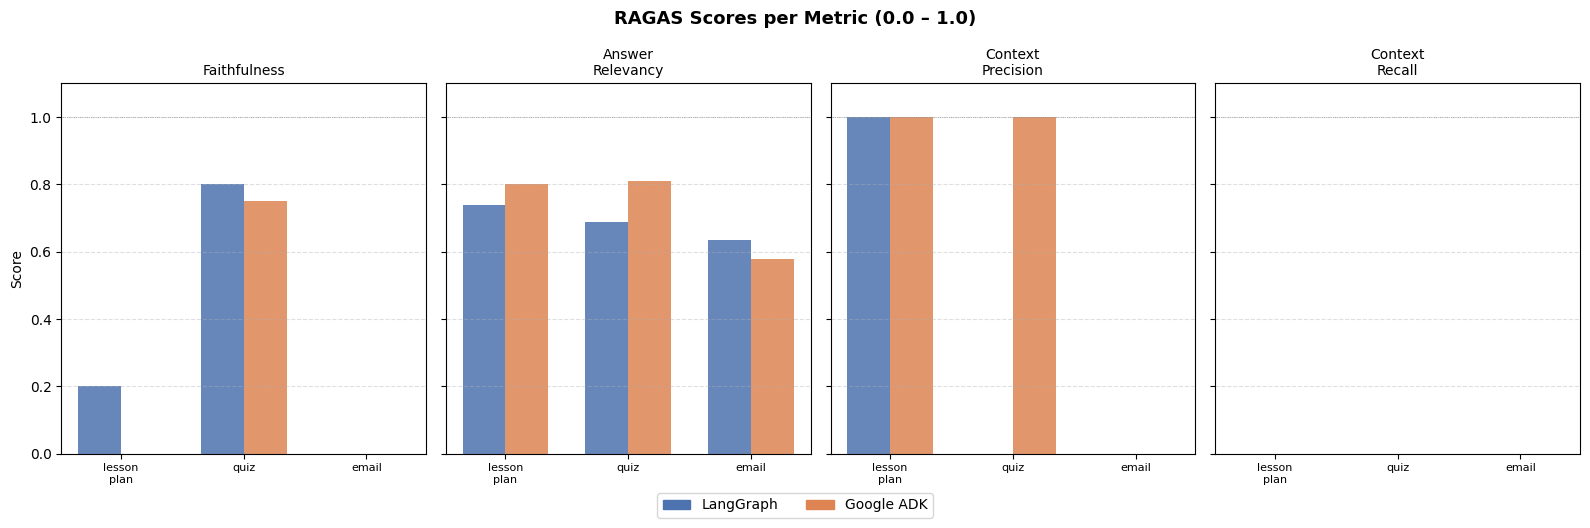

Chart 1 saved: ragas_bar.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

SCENARIOS_LIST = list(SCENARIOS.keys())
FRAMEWORKS = ["LangGraph", "Google ADK"]
COLORS = {"LangGraph": "#4C72B0", "Google ADK": "#DD8452"}
METRIC_LABELS = ["Faithfulness", "Answer\nRelevancy", "Context\nPrecision", "Context\nRecall"]

# ── Chart 1: Grouped bar per metric per framework ──────────────────
fig, axes = plt.subplots(1, len(RAGAS_COLS), figsize=(16, 5), sharey=True)
fig.suptitle("RAGAS Scores per Metric (0.0 – 1.0)", fontsize=13, fontweight="bold")

for ax, metric, label in zip(axes, RAGAS_COLS, METRIC_LABELS):
    x = np.arange(len(SCENARIOS_LIST))
    width = 0.35
    for i, fw in enumerate(FRAMEWORKS):
        sub = df_all[df_all["framework"] == fw]
        vals = [sub[sub["scenario"] == sc][metric].mean() for sc in SCENARIOS_LIST]
        ax.bar(x + i*width - width/2, vals, width, label=fw, color=COLORS[fw], alpha=0.85)
    ax.set_title(label, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([s.replace("_","\n") for s in SCENARIOS_LIST], fontsize=8)
    ax.set_ylim(0, 1.1)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.axhline(1.0, color="gray", linewidth=0.5, linestyle=":")

axes[0].set_ylabel("Score", fontsize=10)
handles = [plt.Rectangle((0,0),1,1, color=COLORS[fw]) for fw in FRAMEWORKS]
fig.legend(handles, FRAMEWORKS, loc="lower center", ncol=2, fontsize=10, bbox_to_anchor=(0.5,-0.05))
plt.tight_layout()
plt.savefig("ragas_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 1 saved: ragas_bar.png")

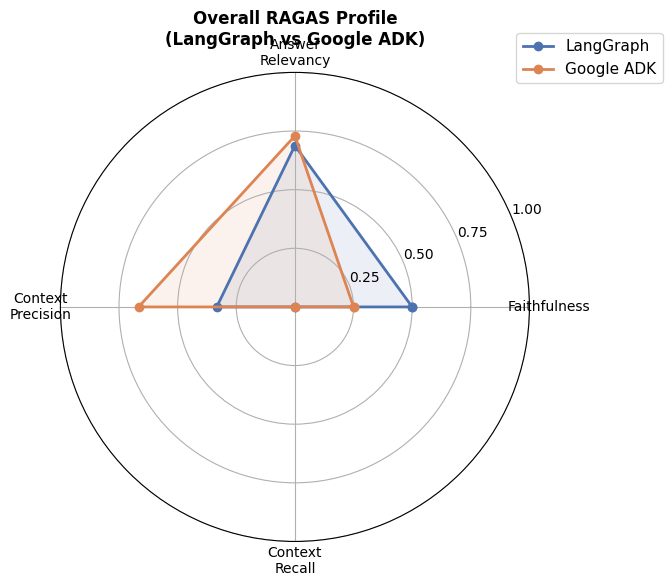

Chart 2 saved: ragas_radar.png


In [ ]:
# ── Chart 2: Radar chart ───────────────────────────────────────────
N = len(RAGAS_COLS)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(7,7), subplot_kw={"polar": True})
ax.set_title("Overall RAGAS Profile\n(LangGraph vs Google ADK)", fontsize=12, fontweight="bold", pad=20)

for fw in FRAMEWORKS:
    sub = df_all[df_all["framework"] == fw]
    vals = [sub[m].mean() for m in RAGAS_COLS] + [sub[RAGAS_COLS[0]].mean()]
    ax.plot(angles, vals, "o-", linewidth=2, color=COLORS[fw], label=fw)
    ax.fill(angles, vals, alpha=0.1, color=COLORS[fw])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(METRIC_LABELS, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=11)
plt.tight_layout()
plt.savefig("ragas_radar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 2 saved: ragas_radar.png")

/tmp/ipykernel_18451/1214624349.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


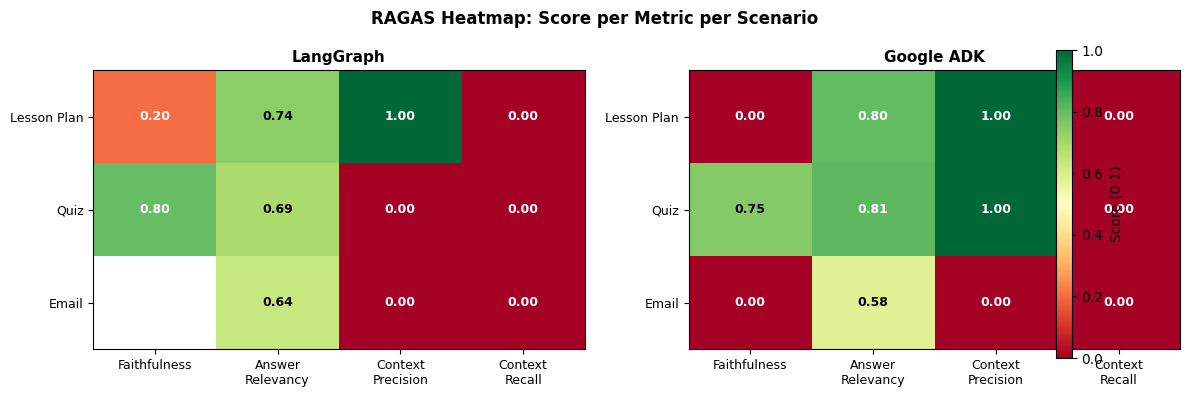

Chart 3 saved: ragas_heatmap.png


In [ ]:
# ── Chart 3: Heatmap ───────────────────────────────────────────────
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("RAGAS Heatmap: Score per Metric per Scenario", fontsize=12, fontweight="bold")

for ax, fw in zip(axes, FRAMEWORKS):
    sub = df_all[df_all["framework"] == fw]
    matrix = []
    for sc in SCENARIOS_LIST:
        row = [sub[sub["scenario"] == sc][m].mean() for m in RAGAS_COLS]
        matrix.append(row)
    matrix = np.array(matrix, dtype=float)

    im = ax.imshow(matrix, vmin=0, vmax=1, cmap="RdYlGn", aspect="auto")
    ax.set_xticks(range(len(RAGAS_COLS)))
    ax.set_xticklabels(METRIC_LABELS, fontsize=9)
    ax.set_yticks(range(len(SCENARIOS_LIST)))
    ax.set_yticklabels([s.replace("_"," ").title() for s in SCENARIOS_LIST], fontsize=9)
    ax.set_title(fw, fontsize=11, fontweight="bold")
    for i in range(len(SCENARIOS_LIST)):
        for j in range(len(RAGAS_COLS)):
            val = matrix[i, j]
            color = "black" if 0.3 < val < 0.8 else "white"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9, color=color, fontweight="bold")

plt.colorbar(im, ax=axes, orientation="vertical", fraction=0.02, label="Score (0-1)")
plt.tight_layout()
plt.savefig("ragas_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 3 saved: ragas_heatmap.png")

## 12 — Export Results

In [ ]:
from datetime import datetime, timezone
from google.colab import files

# Save full scores CSV
scores_csv = "ragas_results.csv"
df_all.to_csv(scores_csv, index=False)
print(f"Saved: {scores_csv} ({len(df_all)} rows)")

# Save markdown report
report_md = "ragas_report.md"
with open(report_md, "w") as f:
    f.write("# RAGAS RAG Faithfulness Evaluation Report\n")
    f.write(f"Generated: {datetime.now(timezone.utc).isoformat()}\n\n")
    f.write("## Metrics\n\n")
    f.write("| Metric | What it measures |\n|---|---|\n")
    f.write("| Faithfulness | Output grounded in retrieved chunks? |\n")
    f.write("| Answer Relevancy | Output relevant to the prompt? |\n")
    f.write("| Context Precision | Retrieved the right chunks? |\n")
    f.write("| Context Recall | Retrieved all needed chunks? |\n\n")
    f.write("## Overall Comparison\n\n")
    f.write("```\n" + overall.to_string() + "\n```\n\n")
    f.write("## Per-Scenario Breakdown\n\n")
    f.write("```\n" + summary.to_string() + "\n```\n\n")
    f.write("## Context Chunks Captured\n\n")
    for sc in SCENARIOS:
        for fw_key, fw_label in [("lg","LangGraph"),("adk","Google ADK")]:
            for run_data in eval_data[sc][fw_key]:
                f.write(f"### {fw_label} | {sc}\n")
                f.write(f"- Contexts retrieved: {len(run_data['contexts'])}\n")
                for i, c in enumerate(run_data['contexts'][:3]):
                    f.write(f"- Chunk {i+1}: {c[:120]}...\n")
                f.write("\n")

print(f"Saved: {report_md}")

files.download(scores_csv)
files.download(report_md)
print("\nDownloads triggered.")